<a href="https://colab.research.google.com/github/gopika-vit/-AI-DS-/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

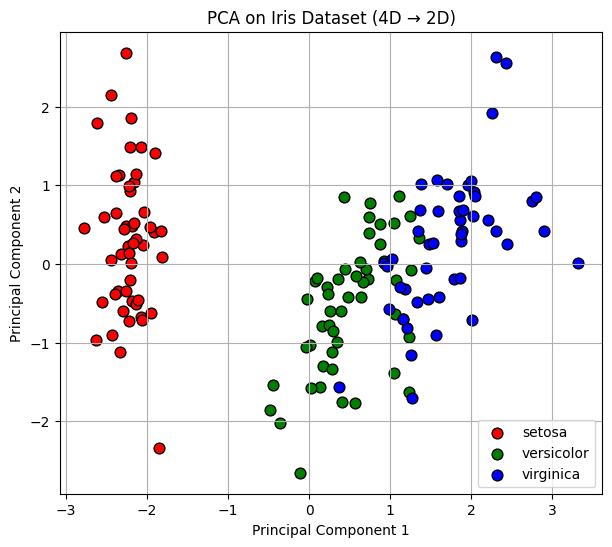

Explained Variance Ratio: [0.72962445 0.22850762]


In [ ]:
#PCA example on the Iris dataset, reducing from 4D → 2D so we can visualize the flower classes clearly.

# PCA on Iris Dataset (4D → 2D)

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

# Plot the PCA results
plt.figure(figsize=(7,6))
colors = ['red', 'green', 'blue']

for i, target in enumerate(target_names):
    subset = pca_df[pca_df['target'] == i]
    plt.scatter(
        subset['PC1'], subset['PC2'],
        color=colors[i], label=target, edgecolors='k', s=60
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset (4D → 2D)')
plt.legend()
plt.grid(True)
plt.show()

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


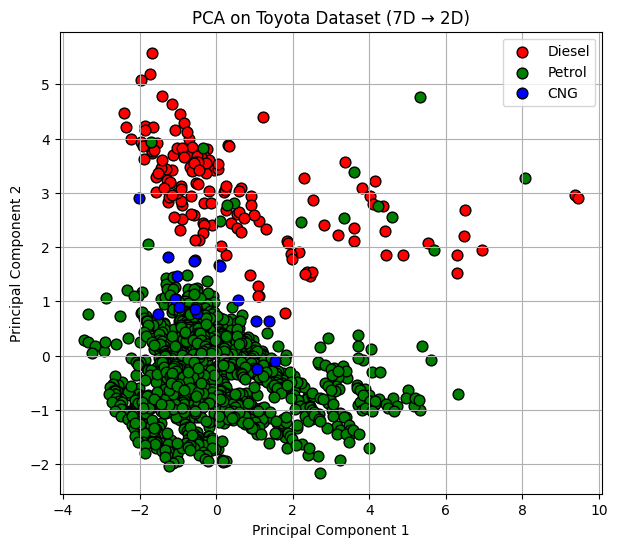

Explained Variance Ratio: [0.40152414 0.24072068]


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Toyota dataset
# Assuming the dataset is already provided as a DataFrame or CSV
data = pd.read_csv('Toyota.csv', na_values=['??', '????'])

# Select features and handle categorical variables
# Convert 'Doors' to numeric (replace 'three' and 'four' with 3 and 4)
data['Doors'] = data['Doors'].replace({'three': 3, 'four': 4, 'five': 5}).astype(float)

# Select numerical features for PCA
numerical_features = ['Price', 'Age', 'KM', 'HP', 'CC', 'Weight', 'Doors']
X = data[numerical_features]

# Handle missing values by filling with median for numerical columns
X = X.fillna(X.median())

# Encode categorical variable 'FuelType' for visualization (not used in PCA)
# We'll use it for coloring the scatter plot
y = data['FuelType'].fillna('Petrol')  # Fill missing FuelType with mode
target_names = y.unique()

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['FuelType'] = y.values

# Plot the PCA results
plt.figure(figsize=(7,6))
colors = ['red', 'green', 'blue', 'purple']  # Adjust based on unique FuelType values
for i, target in enumerate(target_names):
    subset = pca_df[pca_df['FuelType'] == target]
    plt.scatter(
        subset['PC1'], subset['PC2'],
        color=colors[i % len(colors)], label=target, edgecolors='k', s=60
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Toyota Dataset (7D → 2D)')
plt.legend()
plt.grid(True)
plt.show()

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Function to compute and print covariance matrix
def print_covariance_matrix(data, label):
    cov_matrix = np.cov(data.T, bias=True)
    print(f"\nCovariance Matrix for {label} (shape: {cov_matrix.shape}):")
    print(np.round(cov_matrix, 4))

# --- Iris Dataset ---
# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names_iris = iris.target_names

# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Compute covariance matrix of standardized Iris data
print_covariance_matrix(X_iris_scaled, "Iris Standardized Data")

# Apply PCA (reduce to 2 components)
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

# Compute covariance matrix of PCA-transformed Iris data
print_covariance_matrix(X_iris_pca, "Iris PCA-Transformed Data (2D)")



# Explained variance ratio for Iris
print("\nIris Explained Variance Ratio:", pca_iris.explained_variance_ratio_)

# --- Toyota Dataset ---
# Load the Toyota dataset
data = pd.read_csv('Toyota.csv', na_values=['??', '????'])

# Preprocess 'Doors' column
data['Doors'] = data['Doors'].replace({'three': 3, 'four': 4, 'five': 5}).astype(float)

# Select numerical features
numerical_features = ['Price', 'Age', 'KM', 'HP', 'CC', 'Weight', 'Doors']
X_toyota = data[numerical_features]

# Handle missing values by filling with median
X_toyota = X_toyota.fillna(X_toyota.median())

# Encode FuelType for visualization
y_toyota = data['FuelType'].fillna('Petrol')
target_names_toyota = y_toyota.unique()

# Standardize features
scaler_toyota = StandardScaler()
X_toyota_scaled = scaler_toyota.fit_transform(X_toyota)

# Compute covariance matrix of standardized Toyota data
print_covariance_matrix(X_toyota_scaled, "Toyota Standardized Data")

# Apply PCA (reduce to 2 components)
pca_toyota = PCA(n_components=2)
X_toyota_pca = pca_toyota.fit_transform(X_toyota_scaled)

# Compute covariance matrix of PCA-transformed Toyota data
print_covariance_matrix(X_toyota_pca, "Toyota PCA-Transformed Data (2D)")


# Explained variance ratio for Toyota
print("\nToyota Explained Variance Ratio:", pca_toyota.explained_variance_ratio_)


Covariance Matrix for Iris Standardized Data (shape: (4, 4)):
[[ 1.     -0.1176  0.8718  0.8179]
 [-0.1176  1.     -0.4284 -0.3661]
 [ 0.8718 -0.4284  1.      0.9629]
 [ 0.8179 -0.3661  0.9629  1.    ]]

Covariance Matrix for Iris PCA-Transformed Data (2D) (shape: (2, 2)):
[[ 2.9185 -0.    ]
 [-0.      0.914 ]]

Iris Explained Variance Ratio: [0.72962445 0.22850762]

Covariance Matrix for Toyota Standardized Data (shape: (7, 7)):
[[ 1.     -0.8447 -0.5659  0.3098  0.1651  0.5812  0.1853]
 [-0.8447  1.      0.4933 -0.1551 -0.1176 -0.4427 -0.153 ]
 [-0.5659  0.4933  1.     -0.3313  0.2963 -0.0265 -0.0358]
 [ 0.3098 -0.1551 -0.3313  1.      0.0567  0.0892  0.0968]
 [ 0.1651 -0.1176  0.2963  0.0567  1.      0.6514  0.1268]
 [ 0.5812 -0.4427 -0.0265  0.0892  0.6514  1.      0.3026]
 [ 0.1853 -0.153  -0.0358  0.0968  0.1268  0.3026  1.    ]]

Covariance Matrix for Toyota PCA-Transformed Data (2D) (shape: (2, 2)):
[[ 2.8107 -0.    ]
 [-0.      1.685 ]]

Toyota Explained Variance Ratio: [0.40

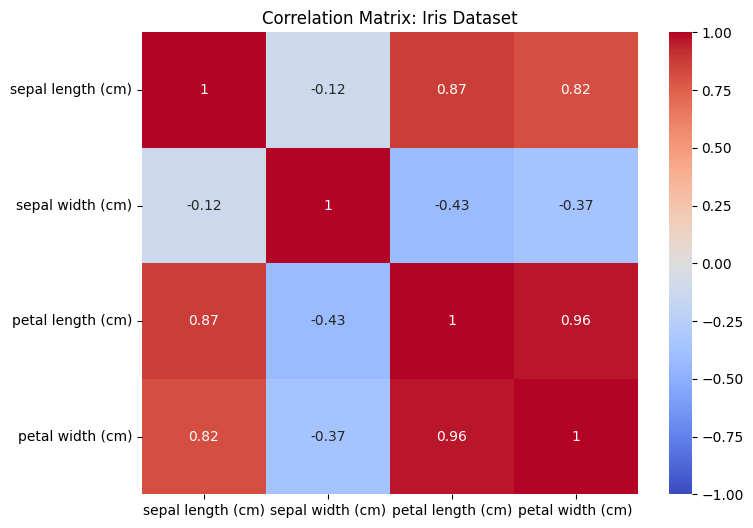

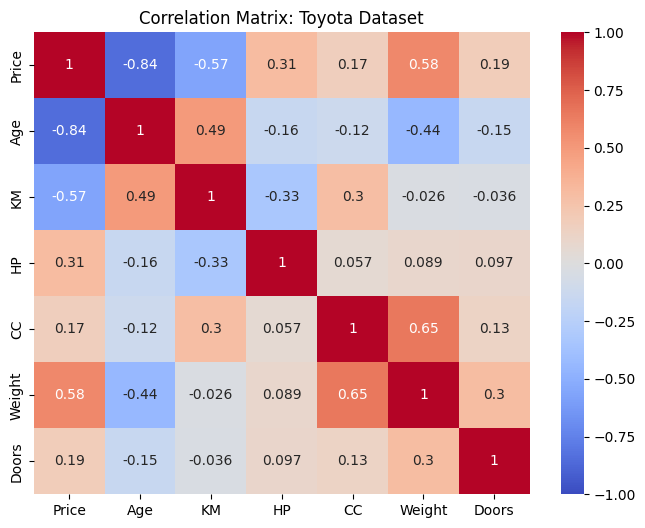

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Function to compute and plot correlation matrix
def plot_correlation_matrix(data, features, title):
    # Compute correlation matrix
    corr_matrix = np.corrcoef(data.T)
    # Create a DataFrame for better visualization
    corr_df = pd.DataFrame(corr_matrix, index=features, columns=features)

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title(f'Correlation Matrix: {title}')
    plt.show()

# --- Iris Dataset ---
# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
iris_features = iris.feature_names

# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Plot correlation matrix for Iris
plot_correlation_matrix(X_iris_scaled, iris_features, "Iris Dataset")

# --- Toyota Dataset ---
# Load the Toyota dataset
data = pd.read_csv('Toyota.csv', na_values=['??', '????'])

# Preprocess 'Doors' column
data['Doors'] = data['Doors'].replace({'three': 3, 'four': 4, 'five': 5}).astype(float)

# Select numerical features
numerical_features = ['Price', 'Age', 'KM', 'HP', 'CC', 'Weight', 'Doors']
X_toyota = data[numerical_features]

# Handle missing values by filling with median
X_toyota = X_toyota.fillna(X_toyota.median())

# Standardize features
scaler_toyota = StandardScaler()
X_toyota_scaled = scaler_toyota.fit_transform(X_toyota)

# Plot correlation matrix for Toyota
plot_correlation_matrix(X_toyota_scaled, numerical_features, "Toyota Dataset")